# TP1- Visualización e interpretación cuantitativa del fenómeno del Niño a partir de productos de Temperatura Superficial del Mar de MODIS/AQUA

In [66]:
# Import libraries
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
import os
print(os.path.abspath(""))

c:\Users\win10\Documents\GitHub\MAIE_devs_pub\Teledt_ambiental\TP1_XXXX


In [3]:
# Load study area vector
#path_vector01 = 'https://raw.githubusercontent.com/francobarrionuevoenv21/MAIE_devs_pub/refs/heads/main/MetodosNumericos/TPE1_Firmas/datos/reflectividad.csv'
path_vector01 = 'Material_ENSO\ONI_region\ONI_zone1.shp'
study_area = gpd.read_file(path_vector01, set_crs = 'EPSG:4326')

c:\Users\win10\anaconda3\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver ESRI Shapefile does not support open option SET_CRS
  return ogr_read(


In [4]:
# Get boundaries limits region analysis vector
minx, miny, maxx, maxy = study_area.bounds.iloc[0, :]
print(minx, miny, maxx, maxy)

-170.0 -5.0 -120.0 5.0


### Serie climatológica de SST a nivel global a partir de MC_SST_sst4 (Climatología 2002-2019)


In [5]:
# Get sst climatology data paths sorted

# Define folder path
directory_path = 'Material_ENSO\monthClima'

# List all files in the directory
all_files = os.listdir(directory_path)

'''# Sort the paths
all_filles_sorted = []

for b in range(len(all_files)):
  for p in all_files:
    if int(p[20]) == (b+1):
      all_filles_sorted.append(p)

#all_filles_sorted'''

'# Sort the paths\nall_filles_sorted = []\n\nfor b in range(len(all_files)):\n  for p in all_files:\n    if int(p[20]) == (b+1):\n      all_filles_sorted.append(p)\n\n#all_filles_sorted'

In [6]:
# Initialize dict mean SST climatology
sstClim_global = {}

In [7]:
# Compute climatology mean global value
for p in all_files:

    sst_mean = xr.open_dataset('Material_ENSO/monthClima/' + p).sst4.mean()
    month = int(p.split('.')[1][-4:-2])

    sstClim_global[month] = sst_mean

#Material_ENSO\monthClima\AQUA_MODIS.20020701_20190731.L3m.MC.SST4.sst4.4km.nc

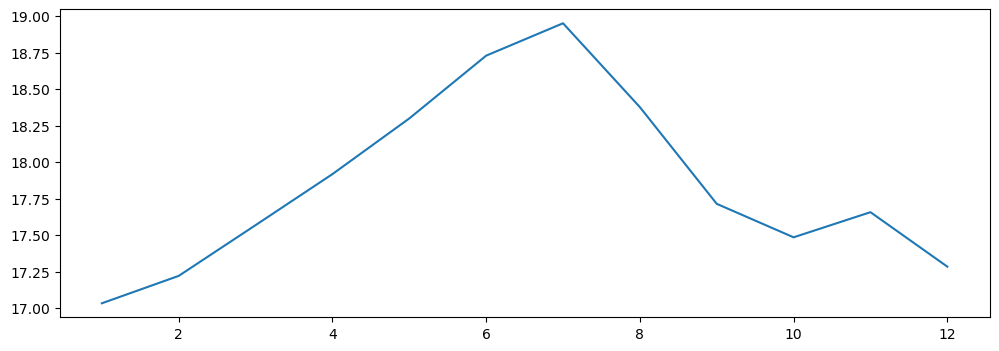

In [8]:
# Plot global climatology timeseries
#clim = np.array([sstClim_global[k] for k in sorted(sstClim_global.keys())]).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sorted(sstClim_global.keys()),
         [sstClim_global[k] for k in sorted(sstClim_global.keys())])#-clim)

### Serie climatológica de SST en ONI 3.4 a partir de MC_SST_sst4 (Climatología 2002-2019)

In [11]:
# Initialize dict mean SST climatology ONI 3.4
sstClim_ONI34 = {}

#
for p in all_files:

    sst_mean = xr.open_dataset('Material_ENSO/monthClima/' + p) \
        .sel(lat=slice(maxy, miny), lon=slice(minx, maxx)).sst4.mean()
    month = int(p.split('.')[1][-4:-2])

    sstClim_ONI34[month] = sst_mean

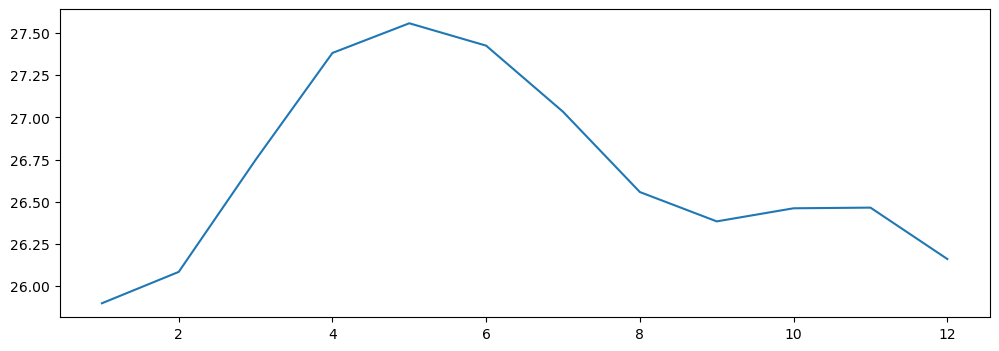

In [12]:
# Plot global climatology timeseries
#clim = np.array([sstClim_global[k] for k in sorted(sstClim_global.keys())]).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sorted(# Initialize dict mean SST climatology ONI 3.4
sstClim_ONI34.keys()),
         [sstClim_ONI34[k] for k in sorted(sstClim_ONI34.keys())])#-clim)

### Cómputo del estadístico climatológico ONI 3.4 (Oct-Nov-Dic)

In [36]:
# Initialize dict mean SST climatology ONI 3.4
sstClim_ONI34_OND = {}

# Define months of interest
list_months = [10, 11, 12]

# Iterate and extract required data
for p in all_files:

    sst4 = xr.open_dataset('Material_ENSO/monthClima/' + p) \
        .sel(lat=slice(maxy, miny), lon=slice(minx, maxx)).sst4
    month = int(p.split('.')[1][-4:-2])

    if month in list_months:
        #print(month)
        sstClim_ONI34_OND[month] = sst4

In [37]:
# Compute mean value climatology ONI 3.4 
meanClimONI34_OND = 0

for ds in sstClim_ONI34_OND.values():
    meanClimONI34_OND += ds

meanClimONI34_OND = meanClimONI34_OND/len(list_months)

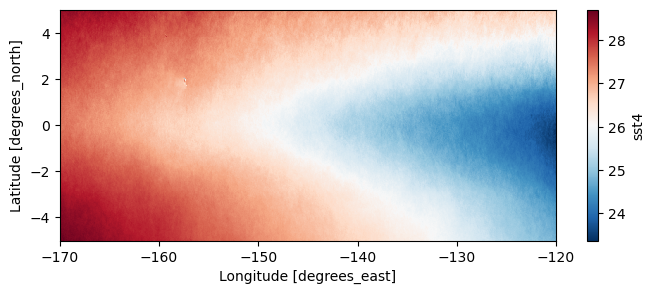

In [39]:
fig, ax = plt.subplots(figsize=(8, 3))
meanClimONI34_OND.plot(ax=ax, cmap='RdBu_r')
#ax.avhline(y=0)

In [52]:
# Compute OCT-NOV-DEC statistic from climatology data in ONI 3.4
meanClim_ONI34 = meanClimONI34_OND.mean() # Climatology oct-nov-dec
print(f'Mean climatology value ONI 3.4 OCT-NOV-DEC: {meanClim_ONI34:.2f}°C')

Mean climatology value ONI 3.4 OCT-NOV-DEC: 26.36°C


### Serie SST en ONI 3.4 a partir de MO_SST_sst4 para OCT-NOV-DEC 2017

In [ ]:
# Get monthly sst 2017 data paths

# Define folder path
directory_path = 'Material_ENSO/2017'

# List all files in the directory
all_files_M02017 = os.listdir(directory_path)

In [48]:
# Initialize dict mean monthyl 2015 SST ONI 3.4
sst2015_ONI34_OND = {}

# Define months of interest
list_months = [10, 11, 12]

# Iterate and extract required data
for p in all_files_M02015:

    sst4 = xr.open_dataset(directory_path+ '/' + p) \
        .sel(lat=slice(maxy, miny), lon=slice(minx, maxx)).sst4
    month = int(p.split('.')[1][-4:-2])

    if month in list_months:
        #print(month)
        sst2015_ONI34_OND[month] = sst4

In [50]:
# Compute mean value climatology ONI 3.4 
mean2015ONI34_OND = 0

for ds in sst2015_ONI34_OND.values():
    mean2015ONI34_OND += ds

mean2015ONI34_OND = mean2015ONI34_OND/len(list_months)

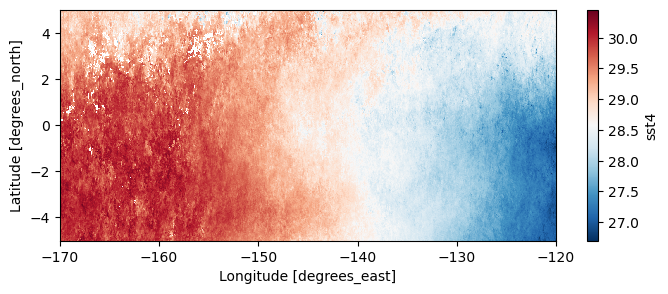

In [51]:
fig, ax = plt.subplots(figsize=(8, 3))
mean2015ONI34_OND.plot(ax=ax, cmap='RdBu_r')

In [ ]:
# Compute OCT-NOV-DEC statistic from 2015 data in ONI 3.4
mean2015_ONI34 = mean2015ONI34_OND.mean() # Climatology oct-nov-dec
print(f'Mean 2015 value ONI 3.4 OCT-NOV-DEC: {mean2015_ONI34:.2f}°C')

Mean 2015 value ONI 3.4 OCT-NOV-DEC: 28.89°C


### Serie SST en ONI 3.4 a partir de MO_SST_sst4 para OCT-NOV-DEC 2017

In [56]:
# Get monthly sst 2017 data paths

# Define folder path
directory_path = 'Material_ENSO/2017'

# List all files in the directory
all_files_M02017 = os.listdir(directory_path)

In [57]:
# Initialize dict mean monthyl 2017 SST ONI 3.4
sst2017_ONI34_OND = {}

# Define months of interest
list_months = [10, 11, 12]

# Iterate and extract required data
for p in all_files_M02017:

    sst4 = xr.open_dataset(directory_path+ '/' + p) \
        .sel(lat=slice(maxy, miny), lon=slice(minx, maxx)).sst4
    month = int(p.split('.')[1][-4:-2])

    if month in list_months:
        #print(month)
        sst2017_ONI34_OND[month] = sst4

In [58]:
# Compute mean value climatology ONI 3.4 
mean2017ONI34_OND = 0

for ds in sst2017_ONI34_OND.values():
    mean2017ONI34_OND += ds

mean2017ONI34_OND = mean2017ONI34_OND/len(list_months)

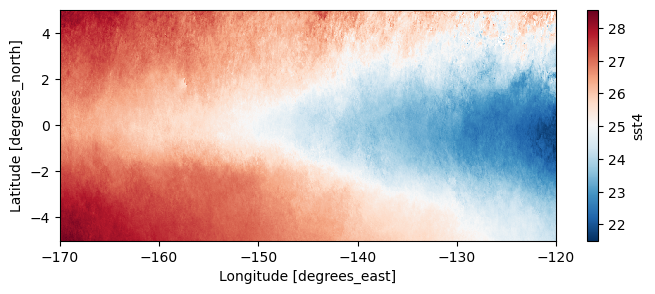

In [59]:
fig, ax = plt.subplots(figsize=(8, 3))
mean2017ONI34_OND.plot(ax=ax, cmap='RdBu_r')

In [60]:
# Compute OCT-NOV-DEC statistic from 2017 data in ONI 3.4
mean2017_ONI34 = mean2017ONI34_OND.mean() # Climatology oct-nov-dec
print(f'Mean 2017 value ONI 3.4 OCT-NOV-DEC: {mean2017_ONI34:.2f}°C')

Mean 2017 value ONI 3.4 OCT-NOV-DEC: 25.51°C


### Cómputo de anomalías de SST en ONI 3.4 para OCT-NOV-DEC 2015 y 2017

In [61]:
# Anomalies computing
anom2015_ONI34 = mean2015_ONI34 - meanClimONI34_OND
anom2017_ONI34 = mean2017_ONI34 - meanClimONI34_OND

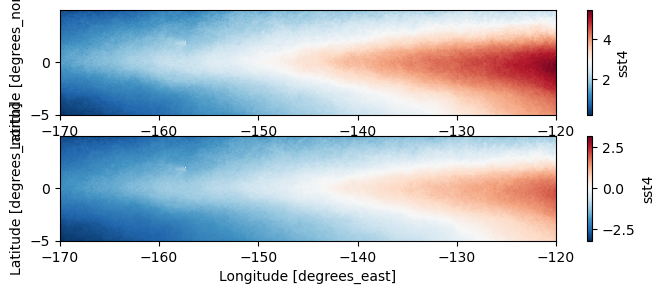

In [63]:
# Anomalies plotting
fig, ax = plt.subplots(2, 1, figsize=(8, 3))
anom2015_ONI34.plot(ax=ax[0], cmap='RdBu_r')
anom2017_ONI34.plot(ax=ax[1], cmap='RdBu_r')

In [65]:
# Compute OCT-NOV-DEC statistic from 2017 data in ONI 3.4
meanAn2015_ONI34 = anom2015_ONI34.mean() # Mean anom
meanAn2017_ONI34 = anom2017_ONI34.mean() # Mean anom
print(f'Mean anomaly 2015 value ONI 3.4 OCT-NOV-DEC: {meanAn2015_ONI34:.2f}°C')
print(f'Mean anomaly 2017 value ONI 3.4 OCT-NOV-DEC: {meanAn2017_ONI34:.2f}°C')

Mean anomaly 2015 value ONI 3.4 OCT-NOV-DEC: 2.53°C
Mean anomaly 2017 value ONI 3.4 OCT-NOV-DEC: -0.86°C


### Comparación ONI datos NOAA vs cómputo por MODIS en ONI 3.4 para OCT-NOV-DEC 2015 y 2017

In [83]:
# Read NOAA data
oni_data = pd.read_csv('Material_ENSO\datos.csv')

# Display dataframe head
oni_data.head(5)

,YR,MON,TOTAL,ClimAdjust,ANOM
0,1950,1,24.56,26.18,-1.62
1,1950,2,25.07,26.39,-1.32
2,1950,3,25.88,26.95,-1.07
3,1950,4,26.29,27.39,-1.11
4,1950,5,26.19,27.56,-1.37


In [84]:
# Filter data

# Define filter values
yr_min = 2015
yr_max = 2020

# Filter oni data
oni_data_filt = oni_data[(oni_data.YR >= yr_min) & (oni_data.YR < yr_max)]

# Define a function that accepts a row
def yymm(row):
    return f"{int(row.YR)}-{int(row.MON)}"

# Create the new column (axis=1 targets rows)
oni_data_filt['yymm'] = oni_data_filt.apply(yymm, axis=1)

# Display filter oni data
oni_data_filt.head(5)


C:\Users\win10\AppData\Local\Temp\ipykernel_95552\4184567306.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  oni_data_filt['yymm'] = oni_data_filt.apply(yymm, axis=1)


,YR,MON,TOTAL,ClimAdjust,ANOM,yymm
780,2015,1,27.06,26.45,0.61,2015-1
781,2015,2,27.18,26.66,0.52,2015-2
782,2015,3,27.77,27.21,0.56,2015-3
783,2015,4,28.53,27.73,0.79,2015-4
784,2015,5,28.85,27.85,1.01,2015-5


In [112]:
[sst.mean() for sst in sst2017_ONI34_OND.values()],
[f'2017-{int(mm)}' for mm in list_months]

['2017-10', '2017-11', '2017-12']

In [110]:
sst2017_ONI34_OND.values()

dict_values([<xarray.DataArray 'sst4' (lat: 240, lon: 1200)> Size: 1MB
array([[28.564999, 28.58    , 28.705   , ..., 26.314999, 26.26    , 26.275   ],
       [28.81    , 28.76    , 28.67    , ..., 26.24    , 26.345   , 26.31    ],
       [28.699999, 28.675   , 28.769999, ..., 26.01    , 26.269999, 26.26    ],
       ...,
       [28.455   , 28.435   , 28.529999, ..., 24.314999, 24.324999, 24.414999],
       [28.48    , 28.349998, 28.435   , ..., 24.38    , 24.324999, 24.465   ],
       [28.41    , 28.414999, 28.48    , ..., 24.515   , 24.515   , 24.51    ]],
      dtype=float32)
Coordinates:
  * lat      (lat) float32 960B 4.979 4.937 4.896 4.854 ... -4.896 -4.938 -4.979
  * lon      (lon) float32 5kB -170.0 -169.9 -169.9 ... -120.1 -120.1 -120.0
Attributes:
    long_name:      4um Sea Surface Temperature
    units:          degree_C
    standard_name:  sea_surface_temperature
    valid_min:      -1000
    valid_max:      10000
    display_scale:  linear
    display_min:    -2.0
    dis

In [119]:
np.array([sst.mean() for sst in sst2017_ONI34_OND.values()]), meanClimONI34_OND.mean().values

(array([25.86151886, 25.47159195, 25.18227577]), array(26.36371422))

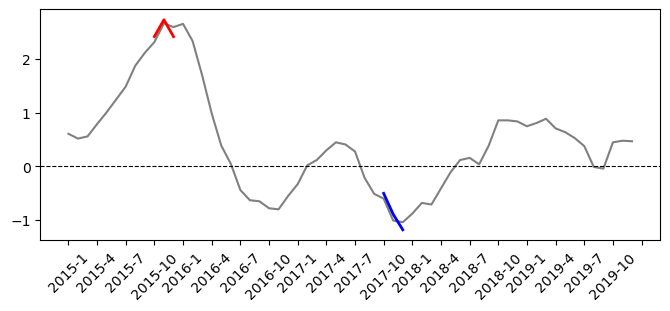

In [127]:
# Plot oni data from 2015 to 2020
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(oni_data_filt.yymm, oni_data_filt.ANOM, color = 'grey', label = 'ONI NOAA')

ax.plot([f'2015-{int(mm)}' for mm in list_months], 
        np.array([sst.mean() for sst in sst2015_ONI34_OND.values()]) - meanClimONI34_OND.mean().values,
        color = 'red', linewidth = 2, label = 'OCT-NOV-DIC 2015')

ax.plot([f'2017-{int(mm)}' for mm in list_months], 
        np.array([sst.mean() for sst in sst2017_ONI34_OND.values()]) - meanClimONI34_OND.mean().values,
        color = 'blue', linewidth = 2, label = 'OCT-NOV-DIC 2017')
 
ax.xaxis.set_major_locator(ticker.MultipleLocator(3)) # space = 3
ax.tick_params(axis='x', rotation=45)

ax.axhline(y=0, linestyle= '--', color = 'black', linewidth = 0.8)
